# DDIM Training on LEMURS 3D Calorimeter Data

See README.md

In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')
# %cd /content/drive/MyDrive/poselab/cern/ddim-transformer/

In [2]:
%pip install --upgrade pip -qqq
%pip install torch torchvision h5py numpy tqdm wandb -qqq

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import math
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
import einops
import datetime
import sys
sys.path.append("../")
from utilities import *

torch.cuda.empty_cache()

In [ ]:
CFG = dict(
    # --- data ---
    data_path   = "../../calo-data/dataset_2_1.hdf5",
    showers_key = "showers",
    energies_key= "incident_energies",
    voxel_shape = (45, 16, 9),
    n_samples   = None,

    # --- model ---
    base_ch   = 16,
    ch_mults  = (1, 2, 4, 8),
    attn_res  = (2,),       # was (4, 2) — drops expensive 704-token level-1 attention
    cond_dim  = 128,
    compile   = False,      # set True on PyTorch 2+ for extra kernel-fusion speedup

    # --- diffusion ---
    T         = 1000,
    beta_min  = 1e-4,
    beta_max  = 0.02,
    schedule  = "cosine",

    # --- training ---
    epochs    = 200,
    batch_size= 64,         # was 16 — 4x fewer steps/epoch
    lr        = 1e-3,       # was 5e-4 — scaled linearly with batch (5e-4 * 64/16)
    grad_clip = 1.0,
    device    = "cuda" if torch.cuda.is_available() else "cpu",
    log_every = 10,

    # --- checkpointing ---
    ckpt_dir  = "checkpoints",
    save_every= 50,
    scratch   = 1,

    # --- wandb logging ---
    wandb_log    = False,
    wandb_project= "ddim_transformers-cern2D",
    wandb_entity = "pgeorgantopoulos-ntua",
)

In [5]:
import wandb

if CFG["wandb_log"]:
    wandb.init(
        entity=CFG["wandb_entity"],
        project=CFG["wandb_project"],
        config = CFG
    )

## Dataset

In [6]:
def ddim_calochallenge_dataloaders(cfg: dict, hlf, log_eps: float = 1e-6,
                                       train_split: float = 0.8):
    """Build CaloChallenge dataloaders with log-normalisation fitted on training data.

    Parameters
    ----------
    cfg : dict
        Must contain ``data_path`` and ``batch_size``.  Optional: ``n_samples``.
    hlf : HighLevelFeatures
        Initialised HLF object matching the dataset's binning XML — passed
        directly to ``CaloChallenge.from_config``.

    Returns
    -------
    train_loader, test_loader, inverse
        ``inverse(x_norm)`` maps a [-1, 1] array/tensor back to raw MeV deposits.
    """
    train_ds, test_ds = CaloChallenge.from_config(cfg, hlf, train_split=train_split)

    logged = np.log(train_ds.showers + log_eps)
    vmin   = float(logged.min())
    vmax   = float(logged.max())

    def forward(shower: np.ndarray, energy_mev: float):
        x    = (np.log(shower + log_eps) - vmin) / (vmax - vmin) * 2 - 1
        cond = math.log10(float(energy_mev) + 1e-9)
        return torch.from_numpy(x).unsqueeze(0).float(), torch.tensor(cond, dtype=torch.float32)

    def inverse(x_norm: np.ndarray) -> np.ndarray:
        return np.exp((x_norm + 1) / 2 * (vmax - vmin) + vmin) - log_eps

    train_ds.transform = test_ds.transform = forward

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False,
                              num_workers=2, pin_memory=True, drop_last=False)
    return train_loader, test_loader, inverse

## Model — 3-D U-Net + Transformer + sinusoidal time embedding + energy conditioning

In [ ]:
def sinusoidal_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    """Sinusoidal time-step embedding (Vaswani et al.)."""
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
    )
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class TimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.SiLU(), nn.Linear(dim * 4, dim * 4),
        )

    def forward(self, t):
        return self.net(sinusoidal_embedding(t, self.dim))  # (B, dim*4)


# ── Building blocks ───────────────────────────────────────────────────────────

class ResBlock3D(nn.Module):
    """3-D residual block conditioned on a combined time+energy embedding."""

    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        self.norm1    = nn.GroupNorm(8, in_ch)
        self.conv1    = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(8, out_ch)
        self.conv2    = nn.Conv3d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch * 2)   # scale + shift (FiLM)
        self.skip     = nn.Conv3d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h              = self.conv1(F.silu(self.norm1(x)))
        scale, shift   = self.emb_proj(F.silu(emb)).chunk(2, dim=-1)
        h              = self.norm2(h) * (1 + scale[..., None, None, None]) \
                         + shift[..., None, None, None]
        return self.conv2(F.silu(h)) + self.skip(x)


class SelfAttn3D(nn.Module):
    """Multi-head self-attention over flattened spatial tokens."""

    def __init__(self, ch: int, heads: int = 4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)

    def forward(self, x):
        B, C, D, H, W = x.shape
        h   = self.norm(x).reshape(B, C, -1).permute(0, 2, 1)   # (B, DHW, C)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).reshape(B, C, D, H, W)


# ── U-Net ─────────────────────────────────────────────────────────────────────

class UNet3D(nn.Module):
    """
    3-D U-Net denoiser for calorimeter showers.

    Args
        x_t  : (B, 1, D, H, W)  noisy shower at step t
        t    : (B,)              diffusion timestep indices  [0, T)
        cond : (B,)              log10(E_inc / GeV)

    Returns
        eps_pred : (B, 1, D, H, W)  predicted noise
    """

    def __init__(self, voxel_shape, base_ch=32, ch_mults=(1, 2, 4, 8),
                 attn_res=(4,), cond_dim=256):
        super().__init__()
        emb_dim  = base_ch * 4          # each half of the combined embedding
        full_emb = emb_dim * 2          # concat(t_emb, cond_emb)
        channels = [base_ch * m for m in ch_mults]
        n_levels = len(channels)

        self.time_emb  = TimeEmbedding(base_ch)
        self.cond_proj = nn.Sequential(
            nn.Linear(1, cond_dim), nn.SiLU(), nn.Linear(cond_dim, emb_dim)
        )

        def _res(i, o): return ResBlock3D(i, o, full_emb)
        def _attn(ch, lvl):
            res = min(voxel_shape) // (2 ** lvl)
            return SelfAttn3D(ch) if res in attn_res else nn.Identity()

        # Encoder
        self.in_conv = nn.Conv3d(1, channels[0], 3, padding=1)
        self.enc     = nn.ModuleList()
        self.downs   = nn.ModuleList()
        ch = channels[0]
        for i, out_ch in enumerate(channels):
            self.enc.append(nn.ModuleList([_res(ch, out_ch), _res(out_ch, out_ch), _attn(out_ch, i)]))
            self.downs.append(
                nn.Conv3d(out_ch, out_ch, 3, stride=2, padding=1) if i < n_levels - 1
                else nn.Identity()
            )
            ch = out_ch

        # Bottleneck — PatchEmbed3D + TransformerBlock replace SelfAttn3D here,
        # giving full-sequence attention with FiLM conditioning at coarsest resolution.
        mid = channels[-1]
        self.mid_r1          = _res(mid, mid)
        self.mid_r2          = _res(mid, mid)
        self.patch_embed_mid = PatchEmbed3D(mid, patch_size=(1, 1, 1), embed_dim=mid)
        self.trans_mid       = TransformerBlock(embed_dim=mid, num_heads=4, cond_embed_dim=full_emb)

        # Decoder (mirror encoder)
        self.dec   = nn.ModuleList()
        self.ups   = nn.ModuleList()
        skip_chs   = list(reversed(channels))
        for i in range(n_levels):
            skip_ch = skip_chs[i]
            out_ch  = skip_chs[i]
            up_ch   = channels[n_levels - 1 - max(0, i - 1)]
            self.ups.append(
                nn.ConvTranspose3d(channels[n_levels - 1 - (i - 1)],
                                   channels[n_levels - 1 - (i - 1)], 2, stride=2)
                if i > 0 else nn.Identity()
            )
            prev = channels[-1] if i == 0 else skip_chs[i - 1]
            self.dec.append(nn.ModuleList([
                _res(prev + skip_ch, out_ch), _res(out_ch, out_ch),
                _attn(out_ch, n_levels - 1 - i),
            ]))

        self.out_norm = nn.GroupNorm(8, channels[0])
        self.out_conv = nn.Conv3d(channels[0], 1, 1)

    def forward(self, x_t, t, cond):
        t_emb = self.time_emb(t)                        # (B, emb_dim)
        c_emb = self.cond_proj(cond.unsqueeze(-1))      # (B, emb_dim)
        emb   = torch.cat([t_emb, c_emb], dim=-1)       # (B, full_emb)

        h = self.in_conv(x_t)
        skips = []
        for (r1, r2, attn), ds in zip(self.enc, self.downs):
            h = r1(h, emb); h = r2(h, emb); h = attn(h)
            skips.append(h)
            h = ds(h)

        # Bottleneck: ResBlock → PatchEmbed3D → TransformerBlock → reshape → ResBlock
        h = self.mid_r1(h, emb)
        B_b, C_b, D_b, H_b, W_b = h.shape
        tokens = self.patch_embed_mid(h)                # (B, D_b*H_b*W_b, mid)
        tokens = self.trans_mid(tokens, emb)            # (B, D_b*H_b*W_b, mid)
        h = einops.rearrange(tokens, 'b (d h w) c -> b c d h w', d=D_b, h=H_b, w=W_b)
        h = self.mid_r2(h, emb)

        for (r1, r2, attn), us, skip in zip(self.dec, self.ups, reversed(skips)):
            h = us(h)
            h = F.interpolate(h, size=skip.shape[2:], mode="nearest")
            h = torch.cat([h, skip], dim=1)
            h = r1(h, emb); h = r2(h, emb); h = attn(h)

        return self.out_conv(F.silu(self.out_norm(h)))

class DDIMScheduler:
    """
    Noise scheduler for DDIM (Song et al., 2021 — arXiv:2010.02502).

    Training: identical to DDPM — samples a random t, adds noise, predicts ε.
    Sampling: deterministic (η=0) or stochastic (η>0) non-Markovian trajectory
              over a sub-sequence of T steps, allowing much fewer NFE.
    """

    def __init__(self, T: int = 1000, beta_min: float = 1e-4,
                 beta_max: float = 0.02, schedule: str = "cosine",
                 device: str = "cpu"):
        self.T      = T
        self.device = device

        if schedule == "linear":
            betas = torch.linspace(beta_min, beta_max, T, device=device)
        elif schedule == "cosine":
            # Nichol & Dhariwal (2021) cosine schedule
            steps = torch.arange(T + 1, device=device) / T
            f     = torch.cos((steps + 0.008) / 1.008 * math.pi / 2) ** 2
            betas = torch.clamp(1 - f[1:] / f[:-1], max=0.999)
        else:
            raise ValueError(f"Unknown schedule: {schedule}")

        alphas      = 1.0 - betas
        alpha_bar   = torch.cumprod(alphas, dim=0)

        self.register("betas",      betas)
        self.register("alphas",     alphas)
        self.register("alpha_bar",  alpha_bar)
        self.register("sqrt_ab",    alpha_bar.sqrt())
        self.register("sqrt_1mab",  (1 - alpha_bar).sqrt())

    def register(self, name, tensor):
        setattr(self, name, tensor)

    # ── Forward (training) ────────────────────────────────────────────────────

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor = None):
        """q(x_t | x_0) = sqrt(ā_t)*x_0 + sqrt(1-ā_t)*ε"""
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_ab[t][:, None, None, None, None]
        s1 = self.sqrt_1mab[t][:, None, None, None, None]
        return s * x0 + s1 * noise, noise

    def training_loss(self, model, x0, cond):
        """Sample random t, corrupt x0, return MSE(ε_pred, ε)."""
        B    = x0.shape[0]
        t    = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        eps_pred   = model(x_t, t, cond)
        return F.mse_loss(eps_pred, noise)

    # ── Reverse (sampling) ────────────────────────────────────────────────────

    @torch.no_grad()
    def ddim_sample(self, model, shape, cond, steps: int = 50, eta: float = 0.0):
        """
        DDIM reverse process.

        Parameters
        ----------
        steps : number of denoising steps  (much less than T)
        eta   : 0 → fully deterministic;  1 → DDPM-equivalent stochasticity
        """
        device = self.device
        x = torch.randn(shape, device=device)

        # Sub-sequence τ evenly spaced in [0, T)
        tau = torch.linspace(self.T - 1, 0, steps + 1, device=device).long()

        for i in range(steps):
            t_cur  = tau[i]
            t_prev = tau[i + 1]
            t_vec  = t_cur.expand(shape[0])

            ab_t   = self.alpha_bar[t_cur]
            ab_prev= self.alpha_bar[t_prev] if t_prev >= 0 else torch.ones(1, device=device)

            eps    = model(x, t_vec, cond)
            x0_hat = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
            x0_hat = x0_hat.clamp(-1, 1)

            sigma  = eta * ((1 - ab_prev) / (1 - ab_t) * (1 - ab_t / ab_prev)).sqrt()
            dir_xt = (1 - ab_prev - sigma ** 2).sqrt() * eps
            noise  = sigma * torch.randn_like(x) if eta > 0 else 0.0
            x      = ab_prev.sqrt() * x0_hat + dir_xt + noise

        return x


# Helper for Swin Transformer style patch merging
def _compute_dims(size, p_size):
    return [s // ps for s, ps in zip(size, p_size)]


class PatchEmbed3D(nn.Module):
    """
    3D Patch Embedding layer.
    Splits 3D input into patches, projects them to an embedding dimension,
    and flattens them into a sequence.
    """
    def __init__(self, in_channels: int, patch_size: tuple, embed_dim: int):
        super().__init__()
        self.patch_size = patch_size
        # Convolution to project patches to embed_dim
        # Stride = patch_size ensures non-overlapping patches
        self.proj = nn.Conv3d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, C, D, H, W)
        # Project patches
        x = self.proj(x)  # (B, embed_dim, D_p, H_p, W_p), where D_p, H_p, W_p are new dimensions

        # Flatten to sequence: (B, N, embed_dim), where N = D_p * H_p * W_p
        x = einops.rearrange(x, 'b c d h w -> b (d h w) c')
        return x

class TransformerBlock(nn.Module):
    """
    A basic Transformer Block with Multi-Head Self-Attention and an MLP.
    Supports conditioning via an embedding (e.g., time/energy).
    """
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: int = 4,
                 dropout_rate: float = 0.1, cond_embed_dim: int = None):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(dropout_rate)
        )

        self.cond_proj = None
        if cond_embed_dim is not None:
            # FiLM-like conditioning on the MLP outputs or inputs
            self.cond_proj = nn.Linear(cond_embed_dim, embed_dim * 2)

    def forward(self, x: torch.Tensor, cond_emb: torch.Tensor = None) -> torch.Tensor:
        # x shape: (B, N, embed_dim)

        # Self-Attention
        identity = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x) # Query, Key, Value
        x = identity + x

        # MLP
        identity = x
        x = self.norm2(x)

        if self.cond_proj is not None and cond_emb is not None:
            scale, shift = self.cond_proj(F.silu(cond_emb)).chunk(2, dim=-1)
            # Apply conditioning (e.g., FiLM to MLP inputs or outputs)
            # Here, applying before MLP, similar to ResBlock3D
            x = x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

        x = self.mlp(x)
        x = identity + x
        return x

## Train

In [ ]:
def train(cfg: dict, train_loader):
    device    = cfg["device"]
    ckpt_dir  = Path(cfg["ckpt_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    model = UNet3D(
        voxel_shape = cfg["voxel_shape"],
        base_ch     = cfg["base_ch"],
        ch_mults    = cfg["ch_mults"],
        attn_res    = cfg["attn_res"],
        cond_dim    = cfg["cond_dim"],
    ).to(device)

    if cfg.get("compile", False):
        model = torch.compile(model)

    scheduler = DDIMScheduler(
        T        = cfg["T"],
        beta_min = cfg["beta_min"],
        beta_max = cfg["beta_max"],
        schedule = cfg["schedule"],
        device   = device,
    )

    n_params = sum(p.numel() for p in model.parameters())
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    vram_gib = (param_bytes + buffer_bytes) / 1024**3
    print(f"  Parameters : {n_params / 1e6:.2f} M")
    print(f"  VRAM       : {vram_gib:.3f} GiB")

    opt    = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sched  = CosineAnnealingLR(opt, T_max=cfg["epochs"], eta_min=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

    start_epoch = 0
    loss_history = []

    if not cfg['scratch']:
        latest = sorted(ckpt_dir.glob("ckpt_epoch*.pt"))
        if latest:
            state = torch.load(latest[-1], map_location=device)
            model.load_state_dict(state["model"])
            opt.load_state_dict(state["opt"])
            sched.load_state_dict(state["sched"])
            if "scaler" in state:
                scaler.load_state_dict(state["scaler"])
            start_epoch = state["epoch"] + 1
            print(f"Resumed from {latest[-1]}  (epoch {start_epoch})")

    for epoch in range(start_epoch, cfg["epochs"]):
        model.train()
        epoch_loss = 0.0

        for x0, cond in train_loader:
            x0, cond = x0.to(device), cond.to(device)

            with torch.autocast("cuda", enabled=(device == "cuda")):
                loss = scheduler.training_loss(model, x0, cond)

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(opt)
            scaler.update()
            opt.zero_grad()

            epoch_loss += loss.item()

        sched.step()
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % cfg['log_every'] == 0:
            print(f"Epoch {epoch+1:4d}/{cfg['epochs']}  |  loss={avg_loss:.5f}"
                  f"  lr={sched.get_last_lr()[0]:.2e}")
            if wandb.run is not None:
                wandb.log({"train_loss": avg_loss, "learning_rate": sched.get_last_lr()[0]}, step=epoch + 1)

        if (epoch + 1) % cfg["save_every"] == 0:
            ckpt_path = ckpt_dir / f"ckpt{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M')}_epoch{epoch+1:04d}.pt"
            torch.save({
                "epoch":  epoch,
                "model":  model.state_dict(),
                "opt":    opt.state_dict(),
                "sched":  sched.state_dict(),
                "scaler": scaler.state_dict(),
                "cfg":    cfg,
            }, ckpt_path)
            print(f"  -> saved {ckpt_path}")

    return model, scheduler, loss_history


print("device:", CFG["device"])

sys.path.append("../CaloChallenge/code")
from HighLevelFeatures import HighLevelFeatures
hlf = HighLevelFeatures('electron', filename='../CaloChallenge/code/binning_dataset_2.xml')

train_loader, _, inverse = ddim_calochallenge_dataloaders(CFG, hlf, train_split=1)

model, scheduler, loss_history_initial = train(CFG, train_loader)

device: cuda
Features in dataset_2_1.hdf5: ['incident_energies', 'showers']
Showers shape: (80000, 6480)
Incident energies shape: (80000, 1)
showers_4d shape: (80000, 9, 16, 45)
Features in dataset_2_1.hdf5: ['incident_energies', 'showers']
Showers shape: (20000, 6480)
Incident energies shape: (20000, 1)
showers_4d shape: (20000, 9, 16, 45)
Train: 80000 | Test: 20000
  Parameters : 7.92 M
  VRAM       : 0.030 GiB


KeyboardInterrupt: 

## Loss Plot for Initial Training

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history_initial)
plt.title('Training Loss Over Epochs (Initial Run)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

NameError: name 'loss_history_initial' is not defined

<Figure size 1000x600 with 0 Axes>

## Load pretrained model

In [ ]:
import torch
from pathlib import Path

def load_model_from_checkpoint(cfg: dict):
    device = cfg["device"]
    ckpt_dir = Path(cfg["ckpt_dir"])
    sorted_checkpoints = sorted(ckpt_dir.glob("ckpt*.pt"))

    if not sorted_checkpoints:
        print("No checkpoint found. Please train a model first or check your ckpt_dir.")
        return None, None

    latest_ckpt_path = sorted_checkpoints[-1]
    print(f"Loading model from {latest_ckpt_path}...")

    state = torch.load(latest_ckpt_path, map_location=device)
    loaded_cfg = state["cfg"]
    print(loaded_cfg)

    model = UNet3D(
        voxel_shape=loaded_cfg["voxel_shape"],
        base_ch=loaded_cfg["base_ch"],
        ch_mults=loaded_cfg["ch_mults"],
        attn_res=loaded_cfg["attn_res"],
        cond_dim=loaded_cfg["cond_dim"],
    ).to(device)
    model.load_state_dict(state["model"])
    model.eval()

    n_params = sum(p.numel() for p in model.parameters())
    param_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
    vram_gib = (param_bytes + buffer_bytes) / 1024**3
    print(f"  Parameters : {n_params / 1e6:.2f} M")
    print(f"  VRAM       : {vram_gib:.3f} GiB")

    scheduler = DDIMScheduler(
        T=loaded_cfg["T"],
        beta_min=loaded_cfg["beta_min"],
        beta_max=loaded_cfg["beta_max"],
        schedule=loaded_cfg["schedule"],
        device=device,
    )

    print(f"Model loaded from epoch {state['epoch'] + 1}.")
    return model, scheduler

model, scheduler = load_model_from_checkpoint(CFG)

## Eval

In [ ]:
import matplotlib.pyplot as plt
import h5py

def generate(model, scheduler, cfg, inverse, n_samples=4, e_inc_gev=10.0,
             ddim_steps=50, eta=0.0):
    """Generate shower samples conditioned on a fixed incident energy."""
    model.eval()
    device = cfg["device"]
    D, H, W = cfg["voxel_shape"]

    cond  = torch.full((n_samples,), math.log10(e_inc_gev), device=device)
    shape = (n_samples, 1, D, H, W)

    with torch.no_grad():
        samples = scheduler.ddim_sample(model, shape, cond,
                                        steps=ddim_steps, eta=eta)

    x = samples.clamp(-1, 1).cpu().numpy()   # (N, 1, D, H, W), in [-1, 1]
    x = inverse(x)              # back to physical MeV
    return x                    # (N, 1, D, H, W)


# Generate samples conditioned on 64 GeV (a common mid-range energy in dataset)
E_INC_GEV = 64.0

gen = generate(model, scheduler, CFG, inverse=inverse,
               n_samples=500, e_inc_gev=E_INC_GEV).squeeze(1)  # (N, D, H, W)

# Load GT showers at the matching energy (±factor 2 window)
with h5py.File(CFG["data_path"], "r") as f:
    all_E = f[CFG["energies_key"]][:].flatten()  # MeV
    all_showers = f[CFG["showers_key"]][:]

E_mev = E_INC_GEV * 1000
mask = (all_E > E_mev / 2) & (all_E < E_mev * 2)
gt = all_showers[mask][:500].reshape(-1, *CFG["voxel_shape"])  # (N, D, H, W)
print(f"Generated: {gen.shape}  |  GT (matched energy): {gt.shape}"
      f"  |  GT E range: {all_E[mask].min()/1000:.1f}–{all_E[mask].max()/1000:.1f} GeV")

## Visualizing all layers in polar coordinates

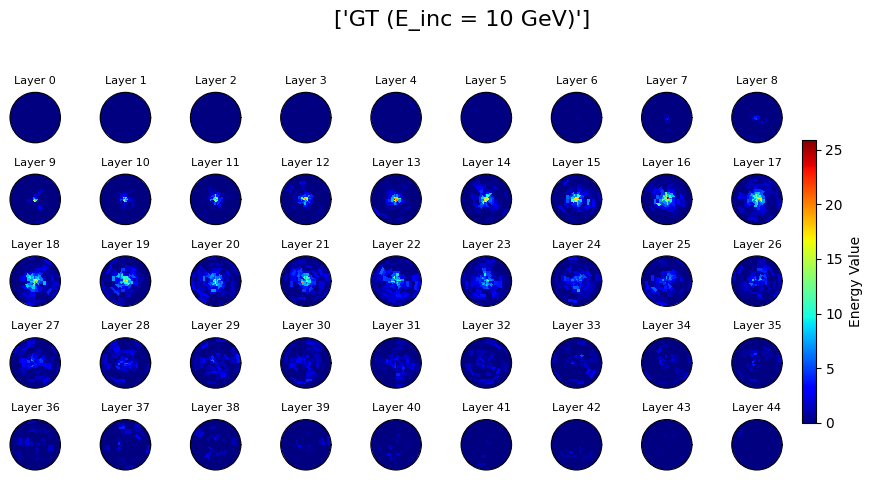

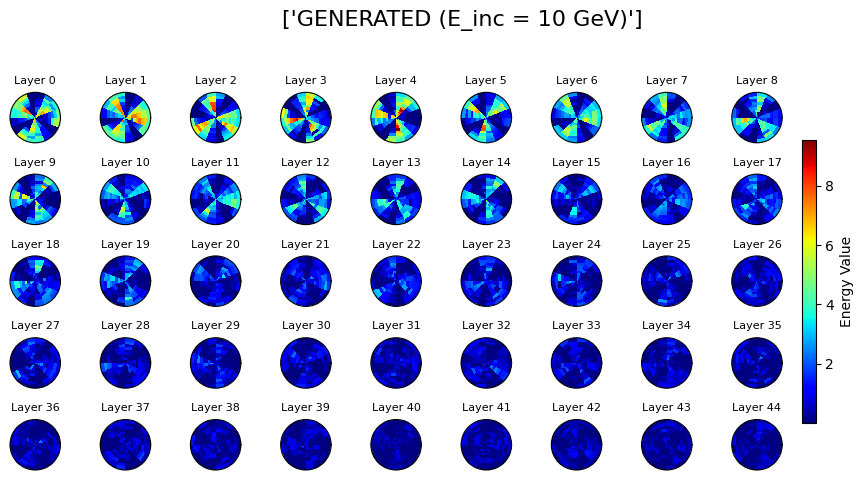

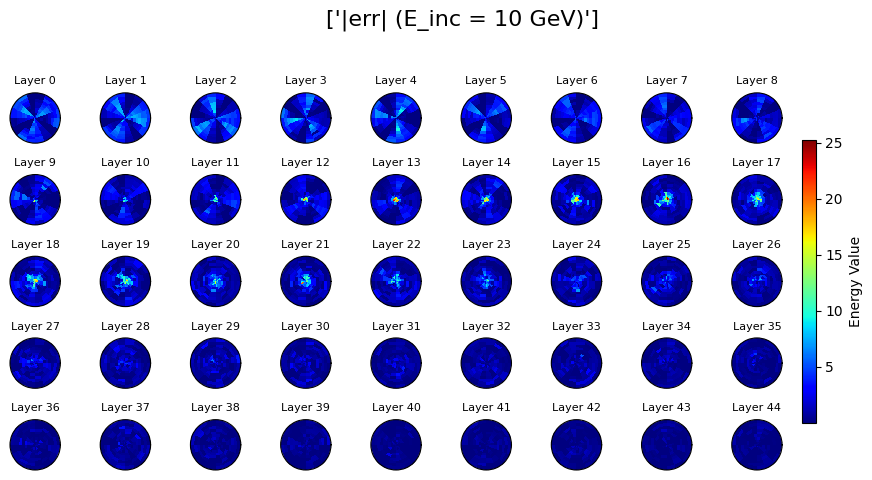

In [ ]:
from os import get_terminal_size
import matplotlib.pyplot as plt
import numpy as np

def plot_layers(shower_data,title):

  # Select the first generated shower sample and remove the channel dimension
  # The shape is (D, H, W) = (45, 16, 9)

  D, H, W = CFG["voxel_shape"] # D=depth, H=angular (N_alpha), W=radial (N_r)

  # Define the bin edges for polar coordinates
  # Angles range from 0 to 2*pi, creating H+1 edges for H angular bins
  theta_edges = np.linspace(0, 2 * np.pi, H + 1)
  # Radii range from 0 to W, creating W+1 edges for W radial bins
  rho_edges = np.arange(W + 1)

  # Create a figure with 45 subplots arranged in a 5x9 grid
  fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(10, 5),
                          subplot_kw={'projection': 'polar'})
  axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

  fig.suptitle([title+" (E_inc = 10 GeV)"], fontsize=16)

  # Determine global min/max for consistent colormap across all subplots
  global_min = shower_data.min()
  global_max = shower_data.max()

  for i in range(D): # Iterate through each depth layer (0 to 44)
      ax = axes[i]
      layer = shower_data[i] # Current layer data, shape (H, W)

      # pcolormesh expects Z to be (len(rho_edges)-1, len(theta_edges)-1) for 1D theta_edges, rho_edges
      # Our `layer` is (H, W). To match (W, H) for Z, we need to transpose it.
      mesh = ax.pcolormesh(theta_edges, rho_edges, layer.T,
                          cmap='jet', vmin=global_min, vmax=global_max)

      ax.set_title(f"Layer {i}", fontsize=8)
      ax.set_xticks([]) # Remove angular ticks
      ax.set_yticks([]) # Remove radial ticks
      ax.grid(False)    # Remove polar grid lines

  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

  # Add a single colorbar for the entire figure
  cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.75, pad=0.02)
  cbar.set_label('Energy Value')

  plt.show()

plot_layers(gt[0],'GT')
plot_layers(gen[0],'GENERATED')
plot_layers(np.abs(gt[0]-gen[0]),'|err|')

## Z-profile

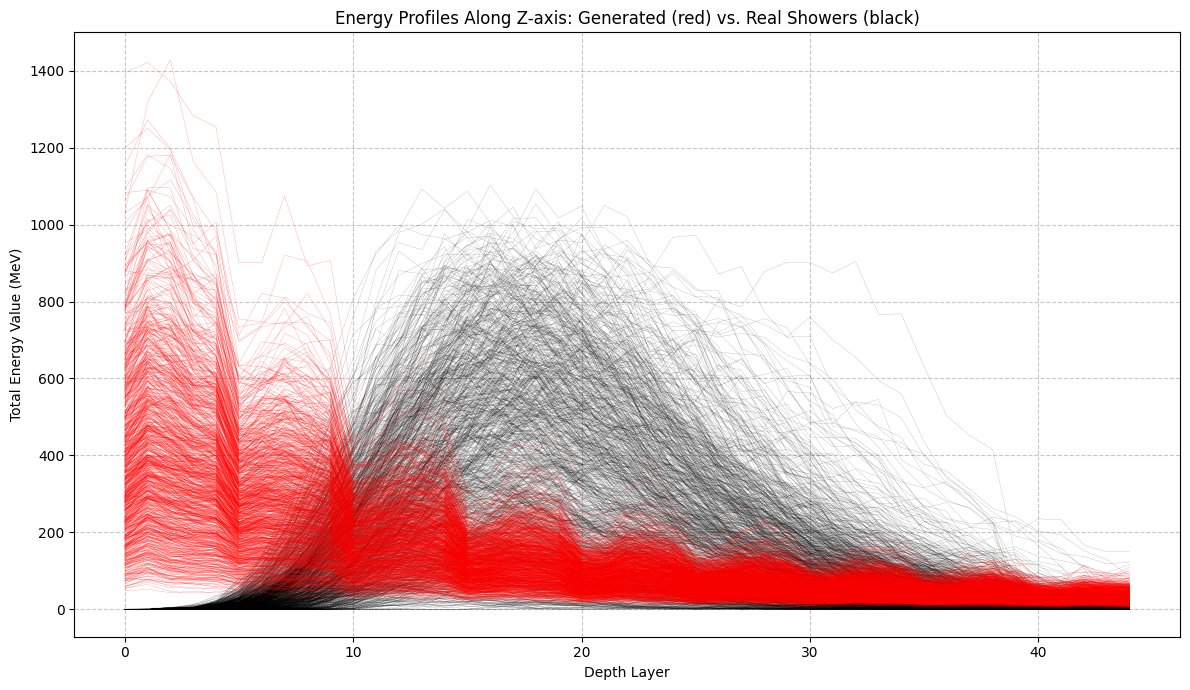

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

D, H, W = CFG["voxel_shape"]

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(np.arange(D), gt.sum(axis=(2, 3)).T, lw=0.1, color='k', linestyle='--')
ax.plot(np.arange(D), gen.sum(axis=(2, 3)).T, lw=0.1, color='r')

ax.set_title("Energy Profiles Along Z-axis: Generated (red) vs. Real Showers (black)")
ax.set_xlabel("Depth Layer")
ax.set_ylabel("Total Energy Value (MeV)")
# ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Traversal-profile

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# D, H, W = CFG["voxel_shape"]
# n_cells = H * W
# cell_idx = np.arange(n_cells)

# gen_energy  = gen.reshape(-1, n_cells) # (N, H*W)

# real_energy = gt.reshape(-1, n_cells) # (N, H*W)

# print(gen_energy.shape, real_energy.shape)
# fig, ax = plt.subplots(figsize=(14, 5))

# ax.semilogy(cell_idx, gen_energy.T,lw=0.2,color='k')
# ax.semilogy(cell_idx, real_energy.T,lw=0.2,color='r',ls='--')

# ax.set_title('Per-Cell Energy Distribution: Generated vs. Real Showers')
# ax.set_xlabel('Cell Index')
# ax.set_ylabel('Energy')
# # ax.legend()
# ax.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

## Traversal-profile (polar)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

D, H, W = CFG["voxel_shape"]

# Sum over depth only -> (H, W): full angular + radial transverse profile
gen_2d  = gen.sum(1).mean(0)
real_2d = gt.sum(1).mean(0)

# Polar bin edges matching plot_layers convention
theta_edges = np.linspace(0, 2 * np.pi, H + 1)
rho_edges   = np.arange(W + 1)

vmin = real_2d.min()
vmax = real_2d.max()
# vmin = min(gen_2d.min(), real_2d.min())
# vmax = max(gen_2d.max(), real_2d.max())

fig, (ax_gen, ax_real) = plt.subplots(1, 2, figsize=(10, 5),
                                       subplot_kw={'projection': 'polar'})
fig.suptitle('Transverse Shower Profile: Generated vs. Real (E_inc = 10 GeV)', fontsize=14)

for ax, data_2d, title in [
    (ax_gen,  gen_2d,  'Generated (first sample)'),
    (ax_real, real_2d, 'Real (Test Set)'),
]:
    mesh = ax.pcolormesh(theta_edges, rho_edges, data_2d.T,
                         cmap='gist_grey', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

cbar = fig.colorbar(mesh, ax=[ax_gen, ax_real]
                    , orientation='vertical',
                    shrink=0.75, pad=0.01)
cbar.set_label('Total Energy (summed over depth)')

# plt.tight_layout()
plt.show()